# Preparing training data for an AI model

Authors:

## Learning goals
- Prepare training data
- Use napari to check and improve annotations
- Use public imaging data to train an AI model
# some of the code is based on https://github.com/IDR/idr-notebooks/

Public repositories like IDR (https://idr.openmicroscopy.org/) and BIA (https://www.ebi.ac.uk/bioimage-archive/) contain a lot of public data that can be used to train AI models.

IDR data that can be explored via a public OMERO instance. It is also possible to access the raw data in Python and use it for analysis or training of AI models.

In this tutorial we will use some images part of a large Cell Paining screen.
The images consists of several markers. 

The goal of this tutorial train an AI model to detect nuclei from the actin (phalloidin) channel. This would allow API channel to segment the nuclei. 
This would allow in a new study to use the DAPI channel for another marker.

We can use the DAPI channel available in thedata to create ground-truth segmentations.

Explore the data here in your browser: https://idr.openmicroscopy.org/webclient/?show=screen-1952

The paper related to the data is linked directly at the IDR, but you can also check it out here directly: https://doi.org/10.1371/journal.pone.0080999  

## Setup

While the IDR is based on OMERO, it is not anymore possible to access the data through the OMERO API (Application Programming Interface). Instead the data can be explored programaticaly via a web API. Then you can find the right data you like to use. The data is stored as OME-zarr files.

In [2]:
# Explore data
from IPython.display import display, HTML
import requests


In [3]:
IDR_BASE_URL = "https://idr.openmicroscopy.org"
MAP_URL = "{base}/webclient/api/annotations/?type=map&{type}={screen_id}"
PLATES_URL = "{base}/webclient/api/plates/?id={screen_id}"

# Here we need to set the screen ID for the dataset we want to explore. 
# The screen ID is a unique identifier for a specific dataset in the IDR (Image Data Resource). 
# You can find the screen ID in the URL of the dataset page on the IDR website. 
# For example, if the URL is "https://idr.openmicroscopy.org/webclient/?show=screen-1952", then the screen ID is 1952.
SCREEN_ID = 1952

We need to create a "http" session which we can use to extract metadata from the IDR

In [4]:
INDEX_PAGE = f"{IDR_BASE_URL}/webclient/?experimenter=-1"
# create http session
with requests.Session() as session:
    request = requests.Request('GET', INDEX_PAGE)
    prepped = session.prepare_request(request)
    response = session.send(prepped)
    if response.status_code != 200:
        response.raise_for_status()
print(f"Connected to IDR at {IDR_BASE_URL} with status code {response.status_code}")

Connected to IDR at https://idr.openmicroscopy.org with status code 200


Now we can print some information of the study (That information is also available on the website)

In [5]:
# Now we can print the metadata available on this screen
qs = {'base': IDR_BASE_URL, 'type': 'screen', 'screen_id': SCREEN_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)


Sample Type cell
Organism Homo sapiens
Study Title Human U2OS cells - compound-profiling Cell Painting experiment
Study Type high content screen
Screen Type primary screen
Screen Technology Type compound screen
Imaging Method fluorescence microscopy
Publication Title Multiplex cytological profiling assay to measure diverse cellular states.
Publication Authors Gustafsdottir SM, Ljosa V, Sokolnicki KL, Anthony Wilson J, Walpita D, Kemp MM, Petri Seiler K, Carrel HA, Golub TR, Schreiber SL, Clemons PA, Carpenter AE, Shamji AF
PubMed ID 24312513 https://www.ncbi.nlm.nih.gov/pubmed/24312513
PMC ID PMC3847047 https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3847047
Publication DOI 10.1371/journal.pone.0080999 https://doi.org/10.1371/journal.pone.0080999
Release Date 2017-09-22
License CC0 1.0 https://creativecommons.org/publicdomain/zero/1.0/
Copyright Waived by Anne Carpenter
External URL https://www.broadinstitute.org/bbbc/BBBC022/
External URL http://www.cellimagelibrary.org/pages/project_202

We can for example also ask which plates are 

In [6]:
qs = {'base': IDR_BASE_URL, 'screen_id': SCREEN_ID}
url = PLATES_URL.format(**qs)

for p in session.get(url).json()['plates']:
    plate_id = p['id']
    print("Plate ID: {id}, Name: {name}".format(**p))
    # create a dictionary with plated id and name


Plate ID: 4403, Name: 20585
Plate ID: 5352, Name: 20586
Plate ID: 4705, Name: 20589
Plate ID: 4881, Name: 20590
Plate ID: 4883, Name: 20591
Plate ID: 4884, Name: 20592
Plate ID: 4886, Name: 20593
Plate ID: 4887, Name: 20594
Plate ID: 4889, Name: 20595
Plate ID: 4890, Name: 20596
Plate ID: 4892, Name: 20607
Plate ID: 4893, Name: 20608
Plate ID: 4895, Name: 20625
Plate ID: 4896, Name: 20626
Plate ID: 4898, Name: 20630
Plate ID: 4899, Name: 20633
Plate ID: 4900, Name: 20639
Plate ID: 4902, Name: 20640
Plate ID: 4903, Name: 20641
Plate ID: 4905, Name: 20646


In [7]:
WELLS_IMAGES_URL = "{base}/webgateway/plate/{plate_id}/{field}/"
plate_id = 4403

qs = {'base': IDR_BASE_URL, 'plate_id': plate_id, 'field': 0}
url = WELLS_IMAGES_URL.format(**qs)
grid = session.get(url).json()
rowlabels = grid['rowlabels']
collabels = grid['collabels']
for r, row in enumerate(grid['grid']):
    for c, cell in enumerate(row):
        if cell is not None:
            well_name = f"{rowlabels[r]}{collabels[c]}"
            print(f"Well: {well_name}, Image: {cell['id']}")

Well: A1, Image: 1895787
Well: A2, Image: 1896562
Well: A3, Image: 1898848
Well: A4, Image: 1895977
Well: A5, Image: 1897192
Well: A6, Image: 1898047
Well: A7, Image: 1896535
Well: A8, Image: 1896580
Well: A9, Image: 1896049
Well: A10, Image: 1896589
Well: A11, Image: 1897282
Well: A12, Image: 1897273
Well: A13, Image: 1898533
Well: A14, Image: 1896193
Well: A15, Image: 1898479
Well: A16, Image: 1897930
Well: A17, Image: 1897615
Well: A18, Image: 1897921
Well: A19, Image: 1895986
Well: A20, Image: 1896670
Well: A21, Image: 1898650
Well: A22, Image: 1896310
Well: A23, Image: 1896895
Well: A24, Image: 1896850
Well: B1, Image: 1897093
Well: B2, Image: 1898182
Well: B3, Image: 1896796
Well: B4, Image: 1896814
Well: B5, Image: 1898929
Well: B6, Image: 1896031
Well: B7, Image: 1896859
Well: B8, Image: 1895851
Well: B9, Image: 1898308
Well: B10, Image: 1896922
Well: B11, Image: 1898056
Well: B12, Image: 1897201
Well: B13, Image: 1897723
Well: B14, Image: 1897453
Well: B15, Image: 1896157
Well

Pick one image on check the metadata

In [8]:
# Now we can print the metadata available on a particular image
IMAGE_ID = 1898190
qs = {'base': IDR_BASE_URL, 'type': 'image', 'screen_id': IMAGE_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)

Cell Line U2OS
Compound Name ML9
Compound Name URL https://www.ncbi.nlm.nih.gov/pccompound?term=ML9
Compound Broad Identifier BRD-K68402494-001-04-7
Compound Broad Identifier URL https://pubchem.ncbi.nlm.nih.gov/compound/BRD-K68402494-001-04-7
Compound Broad Identifier Short BRD-K68402494
Compound Source Biomol International Inc.
Compound SMILES Clc1cccc2c(cccc12)S(=O)(=O)N3CCCNCC3
PubChem InChIKey OZSMSRIUUDGTEP-UHFFFAOYSA-N
Dose 7.70 micromolar
Organism Homo sapiens
Channels Hoechst 33342:nucleus;concanavalin A (con A) AlexaFluor488 conjugate:endoplasmic reticulumn;SYTO 14 green fluorescent nucleic acid stain:nucleoli;wheat germ agglutinin (WGA) AlexaFluor594 conjugate:Golgi apparatus and plasma membrane;phalloidin AlexaFluor594 conjugate:F-actin;MitoTracker Deep Red: mitochondria
In Annotated Set yes
GO Annotation GO:0004697 (inhibits protein kinase C activity)


Check which markers are in the image

In [9]:
annotations = session.get(url).json()['annotations']

meta = {k: v for a in annotations for k, v in a["values"]}

channels = [c.split(":", 1) for c in meta["Channels"].split(";")]
channels = {i: (dye.strip(), target.strip()) for i, (dye, target) in enumerate(channels)}

for i, (dye, target) in channels.items():
    print(i, dye, "->", target)


0 Hoechst 33342 -> nucleus
1 concanavalin A (con A) AlexaFluor488 conjugate -> endoplasmic reticulumn
2 SYTO 14 green fluorescent nucleic acid stain -> nucleoli
3 wheat germ agglutinin (WGA) AlexaFluor594 conjugate -> Golgi apparatus and plasma membrane
4 phalloidin AlexaFluor594 conjugate -> F-actin
5 MitoTracker Deep Red -> mitochondria


Get the URL/location of the data for the image we are interested in. 

In [10]:
# Pick one image

IMAGE_DETAILS_URL = "{base}/api/v0/m/images/{image_id}/"
IMAGE_ID = 1898190

qs = {'base': IDR_BASE_URL, 'image_id': IMAGE_ID}
url = IMAGE_DETAILS_URL.format(**qs)

r = session.get(url).json()

# Images backed by OME-Zarr will link to the zarr data via the image externalInfo
image_details = r["data"]["omero:details"]
is_zarr = "externalInfo" in image_details and image_details["externalInfo"]["EntityType"] == "com.glencoesoftware.ngff:multiscales"

print("Is Zarr?", is_zarr)
zarr_url = None
if (is_zarr):
    externalInfo_lsid = image_details["externalInfo"]["Lsid"]
    print(externalInfo_lsid)
    zarr_url = externalInfo_lsid.replace("s3:", "https:").replace("?anonymous=true", "")
    zarr_url = zarr_url.rstrip("/")
    display(HTML(f"Open <a href='https://ome.github.io/ome-ngff-validator/?source={zarr_url}'>image in NGFF-validator</a>"))



Is Zarr? True
s3://livingobjects.ebi.ac.uk/bioimaging-integrator-data/S-BIAD855/781ac3d7-673f-47be-a4d2-3fdf3f477047/781ac3d7-673f-47be-a4d2-3fdf3f477047.zarr/B/2/8?anonymous=true


In [11]:
data = None
if zarr_url:
    import zarr
    import dask.array as da
    img_group = zarr.open(zarr_url)
    attrs = img_group.attrs.asdict()
    ds_paths = [ds["path"] for ds in attrs["multiscales"][0]["datasets"]]
    print("dataset paths", ds_paths)

    # Load dask array for smallest (last) dataset resolution
    data = da.from_zarr(f"{zarr_url}/{ds_paths[-3]}")
    # T, C, Z, Y, X
    print("array shape", data.shape)

dataset paths ['0', '1', '2', '3']
array shape (5, 260, 348)


### Display one of the channels
You can change the channel parameter

extra_dims [2]
(260, 348)


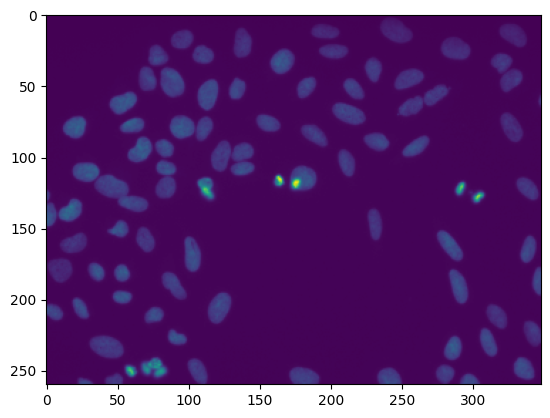

In [12]:
from matplotlib.pyplot import imshow
%matplotlib inline

channel = 2

if data is not None:
    # load the first plane (z, c, t = 0)
    extra_dims = [channel] * (data.ndim - 2)
    print("extra_dims", extra_dims)
    # we slice away any Z/C/T dims, leaving Y and X
    to_slice = (*extra_dims, slice(None), slice(None))
    plane = data[to_slice]
    print(plane.shape)
    # plane is a 2D numpy array
    imshow(plane)



In [13]:
#Get the plane and save as a numpy array
import numpy as np
import matplotlib.pyplot as plt

# data is T, C, Z, Y, X -> pick one channel, first timepoint and z-slice
channel = 2
img = np.asarray(plane)
print("plane shape", img.shape)


plane shape (260, 348)


Let's use skimage thresholding
https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.threshold_otsu

Write the code to compute the Otsu threshold and create a binary mask from the image. 

In [14]:
from skimage.filters import threshold_otsu

thresh = threshold_otsu(image=img)
mask = img > thresh

Use the mask you created and check the result in this plot

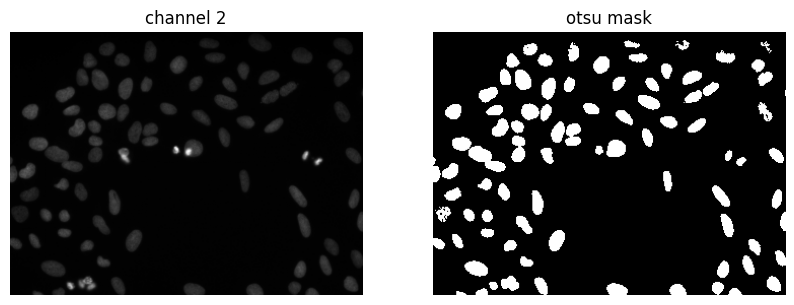

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"channel {channel}")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("otsu mask")
for ax in axes:
    ax.axis("off")

Are you you satisfied with the mask? If not, you can try to adjust the thresholding method or parameters to get a better segmentation.

number of nuclei: 80


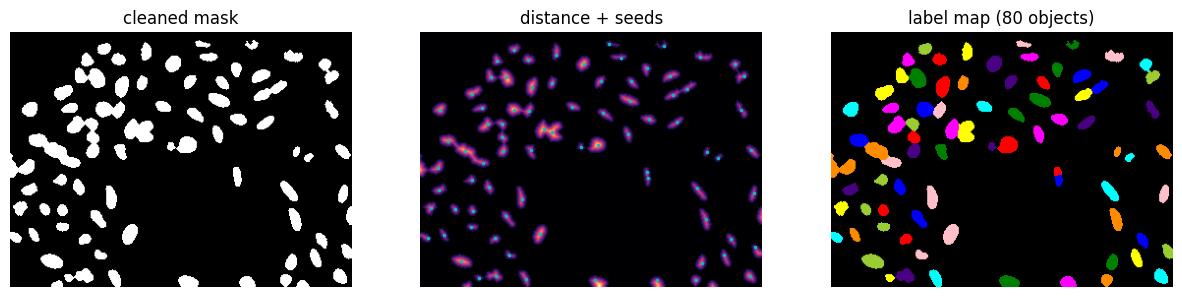

In [16]:
# Split touching nuclei with a watershed and turn the mask into a label map
from scipy import ndimage as ndi
from skimage.morphology import remove_small_objects, closing, disk
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.color import label2rgb

# 1. clean up the binary mask
clean = closing(mask, disk(2))
clean = ndi.binary_fill_holes(clean)
clean = remove_small_objects(clean, max_size=50)   # drops objects <= 50 px

# 2. distance transform: local maxima sit in the middle of each nucleus
distance = ndi.distance_transform_edt(clean)
coords = peak_local_max(distance, min_distance=7, labels=clean)  # tune: ~nucleus radius
markers = np.zeros(distance.shape, dtype=int)
markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)

# 3. flood the inverted distance map from those markers
labels = watershed(-distance, markers, mask=clean)
print("number of nuclei:", labels.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(clean, cmap="gray")
axes[0].set_title("cleaned mask")
axes[1].imshow(distance, cmap="magma")
axes[1].plot(coords[:, 1], coords[:, 0], "c.", markersize=3)
axes[1].set_title("distance + seeds")
axes[2].imshow(label2rgb(labels, bg_label=0))
axes[2].set_title(f"label map ({labels.max()} objects)")
for ax in axes:
    ax.axis("off")


Let's pick 10 images from the plate

In [17]:
# all image ids of the plate (from the well grid above)
# Pick ~10 images from the plate to build a small training set
import random
import zarr
import dask.array as da

TRAIN_CHANNEL = 4    # last channel -> input for the network
NUCLEI_CHANNEL = 2   # channel we threshold to make the labels

image_ids = [c["id"] for row in grid["grid"] for c in row if c is not None]
print("images in plate:", len(image_ids))

random.seed(0)  # same subset every run
subset = random.sample(image_ids, 60)
print("subset:", subset)

image_ids = [c["id"] for row in grid["grid"] for c in row if c is not None]
print("images in plate:", len(image_ids))

random.seed(0)  # same subset every run
subset = random.sample(image_ids, 60)
print("subset:", subset)

images in plate: 384
subset: [1895914, 1896769, 1898650, 1898218, 1896445, 1897894, 1895860, 1898371, 1897003, 1896040, 1897966, 1896094, 1897057, 1898515, 1896940, 1897129, 1896472, 1896499, 1895788, 1898506, 1897903, 1895878, 1898344, 1899064, 1899055, 1897453, 1897102, 1896598, 1895950, 1899037, 1897642, 1898335, 1896778, 1899028, 1896787, 1897975, 1898551, 1898461, 1899163, 1896364, 1898884, 1895851, 1897957, 1896580, 1898398, 1896112, 1896688, 1898038, 1898830, 1896931, 1895787, 1897867, 1896418, 1898416, 1895995, 1899010, 1896121, 1898308, 1897579, 1898686]
images in plate: 384
subset: [1895914, 1896769, 1898650, 1898218, 1896445, 1897894, 1895860, 1898371, 1897003, 1896040, 1897966, 1896094, 1897057, 1898515, 1896940, 1897129, 1896472, 1896499, 1895788, 1898506, 1897903, 1895878, 1898344, 1899064, 1899055, 1897453, 1897102, 1896598, 1895950, 1899037, 1897642, 1898335, 1896778, 1899028, 1896787, 1897975, 1898551, 1898461, 1899163, 1896364, 1898884, 1895851, 1897957, 1896580, 1898

We define a function to load an image 

In [18]:
def load_image(image_id, resolution=-3):
    """Load an IDR image as a dask array (lowest resolution by default)."""
    url = IMAGE_DETAILS_URL.format(base=IDR_BASE_URL, image_id=image_id)
    lsid = session.get(url).json()["data"]["omero:details"]["externalInfo"]["Lsid"]
    zarr_url = lsid.replace("s3:", "https:").replace("?anonymous=true", "").rstrip("/")
    paths = [ds["path"] for ds in zarr.open(zarr_url).attrs.asdict()["multiscales"][0]["datasets"]]
    return da.from_zarr(f"{zarr_url}/{paths[resolution]}")

one image shape (C, Y, X): (5, 260, 348)


Text(0.5, 0.98, 'training input: channel 4')

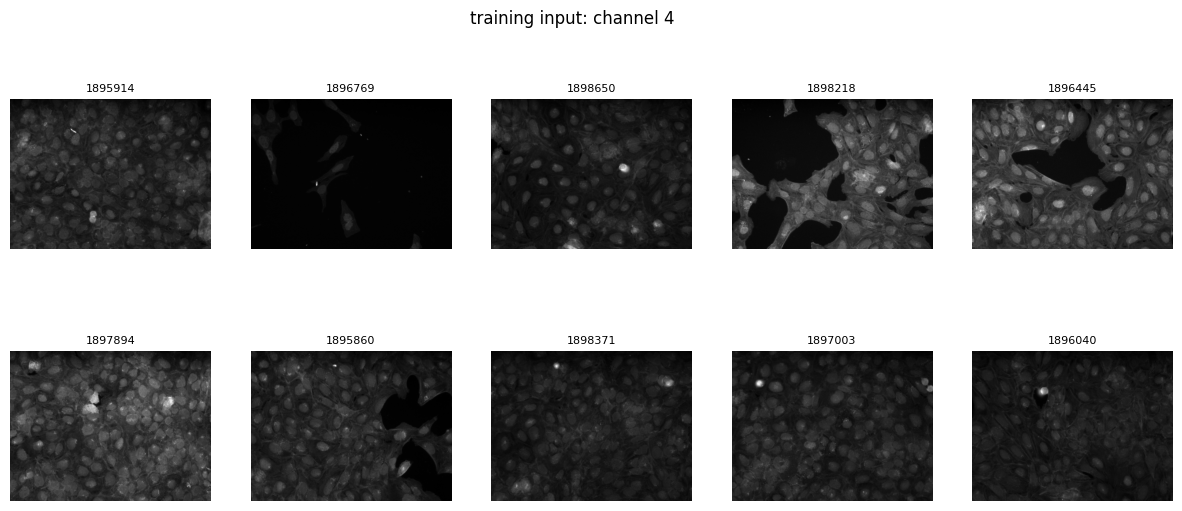

In [19]:
# raw[channel] -> 2D plane, so keep both channels per image
raw = [np.asarray(load_image(i)) for i in subset]
print("one image shape (C, Y, X):", raw[0].shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img, image_id in zip(axes.ravel(), raw, subset):
    ax.imshow(img[TRAIN_CHANNEL], cmap="gray")
    ax.set_title(image_id, fontsize=8)
    ax.axis("off")
fig.suptitle(f"training input: channel {TRAIN_CHANNEL}")


In [21]:
# Save the training data: channel 4 as input image, watershed labels as ground truth
from pathlib import Path
import tifffile

OUT = Path("training_data")
(OUT / "images").mkdir(parents=True, exist_ok=True)
(OUT / "nuclei").mkdir(parents=True, exist_ok=True)
(OUT / "labels").mkdir(parents=True, exist_ok=True)


def segment_nuclei(plane, min_distance=7, max_size=50):
    """Otsu threshold + watershed (same steps as above), returns a label map."""
    mask = plane > threshold_otsu(plane)
    clean = closing(mask, disk(2))
    clean = ndi.binary_fill_holes(clean)
    clean = remove_small_objects(clean, max_size=max_size)
    distance = ndi.distance_transform_edt(clean)
    coords = peak_local_max(distance, min_distance=min_distance, labels=clean)
    markers = np.zeros(distance.shape, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    return watershed(-distance, markers, mask=clean)

n_test_set = 20

for image_id, img in zip(subset[:-20], raw[:-20]):
    labels = segment_nuclei(img[NUCLEI_CHANNEL])
    tifffile.imwrite(OUT / "images" / f"{image_id}.tif", img[TRAIN_CHANNEL])
    tifffile.imwrite(OUT / "nuclei" / f"{image_id}.tif", img[NUCLEI_CHANNEL])
    tifffile.imwrite(OUT / "labels" / f"{image_id}.tif", labels.astype("uint16"))
    print(image_id, "->", labels.max(), "nuclei")

print("saved to", OUT.resolve())

OUT = Path("test_data")
(OUT / "images").mkdir(parents=True, exist_ok=True)
(OUT / "nuclei").mkdir(parents=True, exist_ok=True)
(OUT / "labels").mkdir(parents=True, exist_ok=True)

for image_id, img in zip(subset[-20:], raw[-20:]):
    labels = segment_nuclei(img[NUCLEI_CHANNEL])
    tifffile.imwrite(OUT / "images" / f"{image_id}.tif", img[TRAIN_CHANNEL])
    tifffile.imwrite(OUT / "nuclei" / f"{image_id}.tif", img[NUCLEI_CHANNEL])
    tifffile.imwrite(OUT / "labels" / f"{image_id}.tif", labels.astype("uint16"))
    print(image_id, "->", labels.max(), "nuclei")

print("saved to", OUT.resolve())

1895914 -> 141 nuclei
1896769 -> 12 nuclei
1898650 -> 101 nuclei
1898218 -> 60 nuclei
1896445 -> 84 nuclei
1897894 -> 155 nuclei
1895860 -> 96 nuclei
1898371 -> 122 nuclei
1897003 -> 130 nuclei
1896040 -> 114 nuclei
1897966 -> 118 nuclei


1896094 -> 129 nuclei
1897057 -> 107 nuclei
1898515 -> 90 nuclei
1896940 -> 88 nuclei
1897129 -> 37 nuclei
1896472 -> 97 nuclei
1896499 -> 137 nuclei
1895788 -> 126 nuclei
1898506 -> 72 nuclei
1897903 -> 121 nuclei
1895878 -> 123 nuclei
1898344 -> 140 nuclei
1899064 -> 98 nuclei
1899055 -> 57 nuclei
1897453 -> 100 nuclei
1897102 -> 100 nuclei
1896598 -> 90 nuclei
1895950 -> 105 nuclei
1899037 -> 84 nuclei
1897642 -> 122 nuclei
1898335 -> 131 nuclei
1896778 -> 128 nuclei
1899028 -> 113 nuclei
1896787 -> 120 nuclei
1897975 -> 82 nuclei
1898551 -> 121 nuclei
1898461 -> 96 nuclei
1899163 -> 152 nuclei
1896364 -> 129 nuclei
saved to /home/mpaul2/NL-BioImageAnalysis-course2026/day_3/AI_training/training_data
1898884 -> 134 nuclei
1895851 -> 102 nuclei
1897957 -> 122 nuclei
1896580 -> 59 nuclei
1898398 -> 64 nuclei
1896112 -> 86 nuclei
1896688 -> 97 nuclei
1898038 -> 52 nuclei
1898830 -> 125 nuclei
1896931 -> 96 nuclei
1895787 -> 65 nuclei
1897867 -> 102 nuclei
1896418 -> 128 nuclei
1898416 -

In [ ]:
n_test_set = 20


AttributeError: 'list' object has no attribute 'shape'

The images are saved in a folder `images` and `labels``

## 2. 1 napari for manual annotation correction

In [74]:
# Check the training data in napari: nuclei channel with the saved labels on top
# install with: pip install "napari[all]"
import napari

print("image shapes:", {img.shape[-2:] for img in raw})  # stacking needs one common shape

nuclei = np.stack([img[NUCLEI_CHANNEL] for img in raw])
inputs = np.stack([img[TRAIN_CHANNEL] for img in raw])
# read the labels back from disk, so we check what was actually saved
label_stack = np.stack([tifffile.imread(OUT / "labels" / f"{i}.tif") for i in subset])

viewer = napari.Viewer()
viewer.add_image(nuclei, name=f"channel {NUCLEI_CHANNEL} (nuclei)", colormap="gray")
viewer.add_image(inputs, name=f"channel {TRAIN_CHANNEL} (input)", colormap="green",
                 blending="additive", visible=False)
viewer.add_labels(label_stack, name="segmentation", opacity=0.4)
viewer.dims.axis_labels = ("image", "y", "x")
# use the top slider to step through the 10 images and check each segmentation
napari.run()  # not needed if the notebook already runs %gui qt


image shapes: {(260, 348)}


napari annotation tips and tricks

One nucleus split by 2 labels?
- Use color picker (5), pick color, press bucket (4), and fill the other color

Two nuclei one color
- Press 'new' next to label, take pencil with bursh size 1, draw the line between the nuclei, then bucket to fill the rest



In [75]:
# Fix labels by hand in napari (brush / fill / eraser on the "segmentation" layer),
# then run this cell to write the corrected labels back to disk.
# napari edits label_stack in place, so this works whether the viewer is still open or closed.
for image_id, labels in zip(subset, label_stack):
    tifffile.imwrite(OUT / "labels" / f"{image_id}.tif", labels.astype("uint16"))
    print(image_id, "->", np.unique(labels).size - 1, "nuclei")

print("labels updated in", (OUT / "labels").resolve())


1895914 -> 145 nuclei
1896769 -> 12 nuclei
1898650 -> 102 nuclei
1898218 -> 60 nuclei
1896445 -> 84 nuclei
1897894 -> 155 nuclei
1895860 -> 96 nuclei
1898371 -> 122 nuclei
1897003 -> 130 nuclei
1896040 -> 114 nuclei
labels updated in /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AItraining/training_data/labels


In [ ]:
#sort images into train and validation sets (80/20 split)
from sklearn.model_selection import train_test_split
image_ids = [c["id"] for row in grid["grid"] for c in row if c is not None]
train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=21)
print("train:", len(train_ids), "validation:", len(val_ids))    

# 2.2 stardist inference

In [23]:
from stardist.models import StarDist2D

# prints a list of available models
StarDist2D.from_pretrained()

# creates a pretrained model
model = StarDist2D.from_pretrained('2D_versatile_fluo')

ModuleNotFoundError: No module named 'stardist'

In [24]:
from stardist.data import test_image_nuclei_2d
from stardist.plot import render_label
from csbdeep.utils import normalize
import matplotlib.pyplot as plt

img = test_image_nuclei_2d()

labels, _ = model.predict_instances(normalize(nuclei[0]))

plt.subplot(1,2,1)
plt.imshow(nuclei[0], cmap="gray")
plt.axis("off")
plt.title("input image")

plt.subplot(1,2,2)
plt.imshow(labels)
plt.axis("off")
plt.title("prediction + input overlay")

ModuleNotFoundError: No module named 'stardist'

In [ ]:
https://github.com/stardist/stardist/blob/main/examples/2D/2_training.ipynb

In [ ]:
Cellpose
https://github.com/MouseLand/cellpose/blob/main/notebooks/train_Cellpose-SAM.ipynb

# biapy

In [19]:
train_data_path = '/var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AItraining/training_data/images'
train_data_gt_path = '/var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AItraining/training_data/labels'
patch_size = 256
input_channels = 1
number_of_epochs = 100
percentage_validation = 0.2

In [20]:
import yaml
with open( '2d_instance_segmentation.yaml', 'r') as stream:
    try:
        biapy_config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [21]:
# update paths to data
biapy_config['DATA'] = {}
biapy_config['DATA']['TRAIN'] = {}
biapy_config['DATA']['TRAIN'] ['PATH']= {}
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path


# update data patch size
biapy_config['DATA']['PATCH_SIZE'] = '('+str(patch_size)+', '+ str(patch_size)+', ' + str(input_channels)+')'
# adjust test padding accordingly
# padding = patch_size // 8
# biapy_config['DATA']['TEST']['PADDING'] = '('+str(padding)+', '+ str(padding)+')'

# update training parameters
biapy_config['DATA']['VAL'] = {}
biapy_config['DATA']['VAL']['FROM_TRAIN'] = True
biapy_config['DATA']['VAL']['SPLIT_TRAIN'] = percentage_validation/100.0
biapy_config['TRAIN']={}
biapy_config['TRAIN']['EPOCHS'] = number_of_epochs
if number_of_epochs < 10:
    biapy_config['LOG'] = {}
    biapy_config['LOG']['CHART_CREATION_FREQ'] = 1
biapy_config['TRAIN']['ENABLE'] = True

biapy_config['MODEL']['SOURCE'] = "biapy"

problem_channels = 'BC'

biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = problem_channels
biapy_config['PROBLEM']['INSTANCE_SEG']['DATA_MW_TH_TYPE'] = "auto"

# Transcribe model architecture
# Available models: "U-Net", "Residual U-Net", "Attention U-Net",
# 'MultiResUNet', 'SEUNet', 'ResUNet++', "UNETR-Mini","UNETR-Small"
# "UNETR-Base"
architecture = 'unet'
biapy_config['MODEL']['ARCHITECTURE'] = architecture

# Class rebalance
biapy_config['LOSS'] = {}
biapy_config['LOSS']['CLASS_REBALANCE'] = True

# # learning rate scheduler
# if learning_rate_scheduler == 'One cycle':
#     biapy_config['TRAIN']['LR_SCHEDULER'] = {}
#     biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'onecycle'
# elif learning_rate_scheduler == 'Warm-up cosine decay':
#     biapy_config['TRAIN']['LR_SCHEDULER'] = {}
#     biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'warmupcosine'
#     biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 0.0
#     biapy_config['TRAIN']['LR_SCHEDULER']['WARMUP_COSINE_DECAY_EPOCHS'] = 0
# elif learning_rate_scheduler == 'Reduce on plateau':
#     biapy_config['TRAIN']['LR_SCHEDULER'] = {}
#     biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'reduceonplateau'
#     biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_FACTOR'] = 0.5
#     biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_PATIENCE'] = 5
#     biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 0.00001

# update test parameters

biapy_config['TEST']['ENABLE'] = False

yaml_file = '2d_instance_segmentation_config.yaml'
#save
with open( yaml_file, 'w') as outfile:
    yaml.dump(biapy_config, outfile, default_flow_style=False)

In [22]:
output_path = 'biapy_output'
job_name = "my_model"

In [23]:
from biapy import BiaPy
biapy = BiaPy(config='2d_instance_segmentation_config.yaml', result_dir=output_path, name=job_name, run_id=2, gpu="0")
biapy.run_job()

<Figure size 640x480 with 0 Axes>